           Region         Date Frequency  Estimated Unemployment Rate (%)  \
0  Andhra Pradesh   31-05-2019   Monthly                             3.65   
1  Andhra Pradesh   30-06-2019   Monthly                             3.05   
2  Andhra Pradesh   31-07-2019   Monthly                             3.75   
3  Andhra Pradesh   31-08-2019   Monthly                             3.32   
4  Andhra Pradesh   30-09-2019   Monthly                             5.17   

   Estimated Employed  Estimated Labour Participation Rate (%)   Area  
0          11999139.0                                    43.24  Rural  
1          11755881.0                                    42.05  Rural  
2          12086707.0                                    43.50  Rural  
3          12285693.0                                    43.97  Rural  
4          12256762.0                                    44.68  Rural  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 

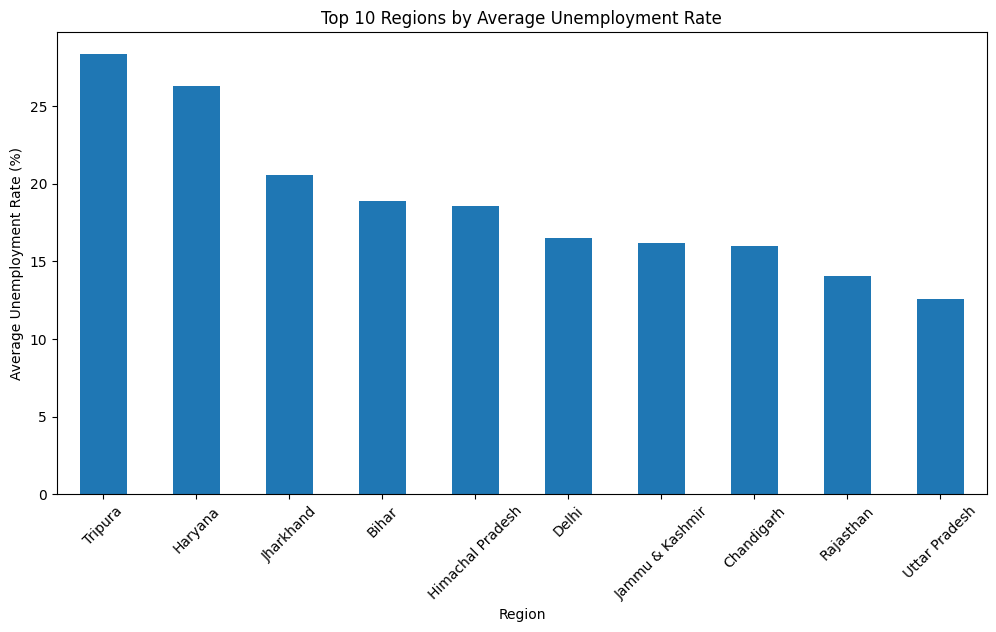

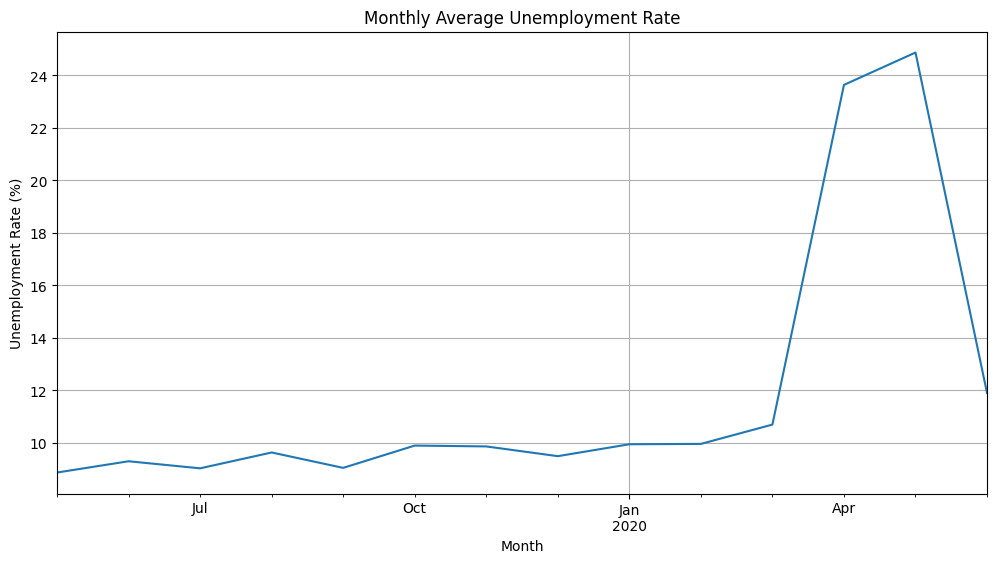

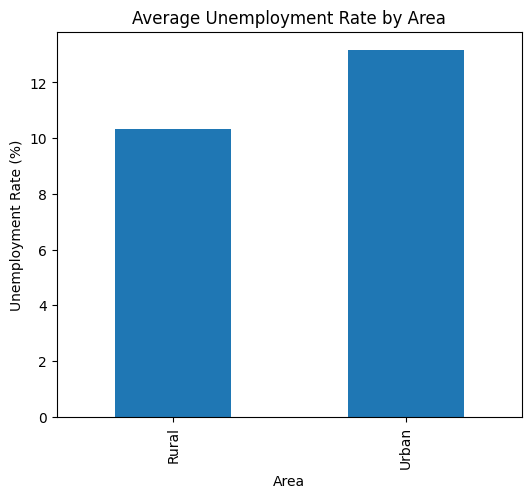

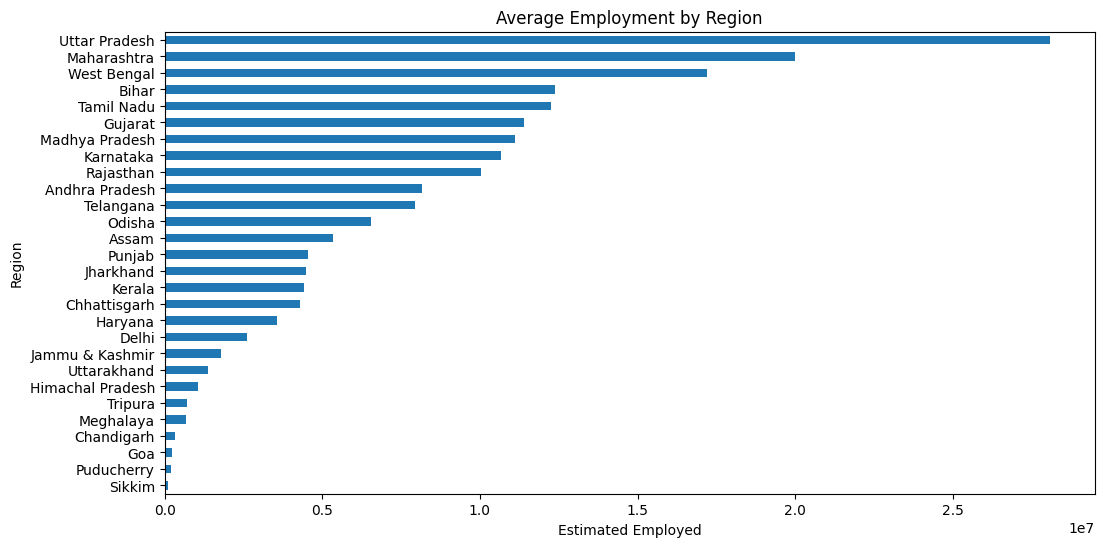

                                         Estimated Unemployment Rate (%)  \
Estimated Unemployment Rate (%)                                 1.000000   
Estimated Employed                                             -0.222876   
Estimated Labour Participation Rate (%)                         0.002558   

                                         Estimated Employed  \
Estimated Unemployment Rate (%)                   -0.222876   
Estimated Employed                                 1.000000   
Estimated Labour Participation Rate (%)            0.011300   

                                         Estimated Labour Participation Rate (%)  
Estimated Unemployment Rate (%)                                         0.002558  
Estimated Employed                                                      0.011300  
Estimated Labour Participation Rate (%)                                 1.000000  


In [2]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("Unemployment in India.csv")

# Remove extra spaces from column names
df.columns = df.columns.str.strip()

# Display first 5 rows
print(df.head())

# Dataset information
print(df.info())

# Check missing values
print(df.isnull().sum())

# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Basic statistics
print(df.describe())

# Average unemployment rate by region
region_unemployment = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False)

print(region_unemployment)

# Plot top 10 regions with highest unemployment
plt.figure(figsize=(12,6))
region_unemployment.head(10).plot(kind='bar')
plt.title("Top 10 Regions by Average Unemployment Rate")
plt.xlabel("Region")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.show()

# Monthly unemployment trend
monthly = df.groupby(df['Date'].dt.to_period('M'))['Estimated Unemployment Rate (%)'].mean()

plt.figure(figsize=(12,6))
monthly.plot()
plt.title("Monthly Average Unemployment Rate")
plt.xlabel("Month")
plt.ylabel("Unemployment Rate (%)")
plt.grid(True)
plt.show()

# Rural vs Urban unemployment
area_avg = df.groupby('Area')['Estimated Unemployment Rate (%)'].mean()

plt.figure(figsize=(6,5))
area_avg.plot(kind='bar')
plt.title("Average Unemployment Rate by Area")
plt.xlabel("Area")
plt.ylabel("Unemployment Rate (%)")
plt.show()

# Employment by region
employment = df.groupby('Region')['Estimated Employed'].mean().sort_values()

plt.figure(figsize=(12,6))
employment.plot(kind='barh')
plt.title("Average Employment by Region")
plt.xlabel("Estimated Employed")
plt.show()

# Correlation matrix
correlation = df[['Estimated Unemployment Rate (%)',
                  'Estimated Employed',
                  'Estimated Labour Participation Rate (%)']].corr()

print(correlation)